In [9]:
import os
import pickle
from pathlib import Path
import pickle
import re
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.pyplot as plt
import h5py
import scipy
from scipy import signal
from tqdm import tnrange
from tqdm import tqdm
import seaborn as sns
from scipy.stats import norm,entropy,linregress
from scipy.optimize import minimize, curve_fit
from scipy.io import savemat
from scipy.special import erf
from sklearn.linear_model import LogisticRegression
from joblib import Parallel, delayed

from scipy.stats import norm,entropy,linregress
from scipy.optimize import minimize, curve_fit
from scipy.io import savemat
from scipy.special import erf

import multiprocess as mp
from multiprocess import Pool
import sys
import warnings

from odor_breathing_functions import*
from functions_beh import*
from data_loader import*
from hdf5_loader_and_aux_functions import*


warnings.filterwarnings('ignore')

cmap = plt.rcParams['axes.prop_cycle'].by_key()['color']
modulename = 'multiprocess'
mpl.rcParams['svg.fonttype'] = 'none'
sns.set_context('poster', font_scale=1.1)

cmap_5 = sns.color_palette("rocket_r", as_cmap=True)(np.linspace(0.1, 0.8, 7))

In [3]:
fig_data = pd.read_parquet("fig_data.parquet", engine="pyarrow")
fig_data = fig_data.loc[(behavior_data['cum_odor'] > -1) & (behavior_data['cum_odor'] < 21)]


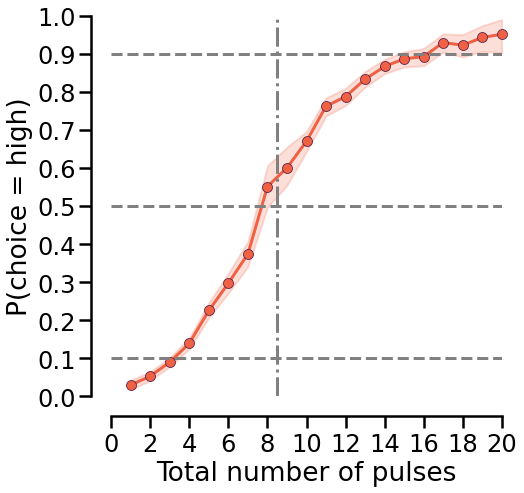

In [12]:
fig, ax = plt.subplots(figsize=(7,7))#= plt.figure(figsize=(7,7))

sns.lineplot(data=fig_data, x='cum_odor', y='high_choice', color=cmap_5[2],  marker='.',markeredgecolor=cmap_5[6], markersize=20, clip_on=False)
plt.xlabel('Total number of pulses')  #'$N_{pulses}$'
plt.axhline(y=0.1,color='gray',linestyle='--')
plt.axhline(y=0.5,color='gray',linestyle='--')
plt.axhline(y=0.9,color='gray',linestyle='--')
plt.axvline(x=8.5,color='gray',linestyle='-.')
plt.ylim(0,1)
plt.xlim(0,20)
plt.yticks(np.linspace(0,1,11))
plt.ylabel('P(choice = high)')  #$P$(choice = left)
plt.xticks(np.linspace(0,20,11))
sns.despine(right=True, top=True, offset=20)
sns.despine(offset=20)

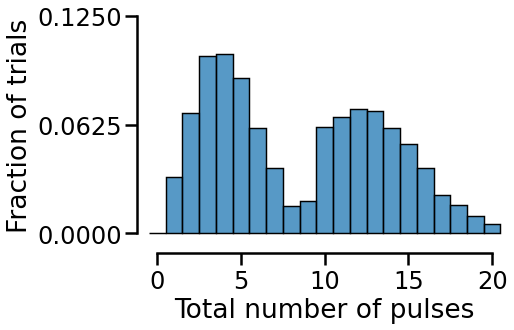

In [20]:
sns.histplot(data=fig_data, x='cum_odor', stat='proportion', binwidth=1, binrange=(-0.5, 20.5), color=cmap[0], edgecolor='black', clip_on=False)
plt.yticks(np.linspace(0,0.125,3))
plt.xlim(0,20)
plt.xlabel('Total number of pulses')  #'$N_{pulses}$'
plt.ylabel('Fraction of trials')  #'$N_{pulses}$'
plt.yticks(np.linspace(0,0.125,3))
sns.despine(offset=20)